In [ ]:
import os
import shutil
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
# -----------------------------------------------------------
# 1.1 Mount Google Drive
# -----------------------------------------------------------
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# -----------------------------------------------------------
# 1.2 Configuration
# -----------------------------------------------------------
# Your actual structure:
#   /content/drive/MyDrive/train_dataset/
#       closed/
#           closedLeftEyes/   ← images here
#           closedRightEyes/  ← images here
#       open/
#           openLeftEyes/     ← images here
#           openRightEyes/    ← images here

RAW_DATASET_PATH  = "/content/drive/MyDrive/train_dataset"
MERGED_DATASET_PATH = "/content/merged_dataset"

IMG_SIZE         = (64, 64)    # Reduced from 224x224
BATCH_SIZE       = 32
VALIDATION_SPLIT = 0.2
RANDOM_SEED      = 42

In [ ]:
# -----------------------------------------------------------
# 1.3 Class map — 2 levels deep
# -----------------------------------------------------------
# binary class → list of sub-sub-folders containing images
CLASS_MAP = {
    "open":   ["open/openLeftEyes",   "open/openRightEyes"],
    "closed": ["closed/closedLeftEyes", "closed/closedRightEyes"]
}

In [ ]:
# -----------------------------------------------------------
# 1.4 Merge function
# -----------------------------------------------------------
def merge_classes(raw_path, merged_path, class_map):
    """
    Walks two levels deep and copies all images into flat binary class folders:
        merged_dataset/open/    ← openLeftEyes + openRightEyes
        merged_dataset/closed/  ← closedLeftEyes + closedRightEyes
    Prefixes filenames with the source sub-folder to avoid name collisions.
    Skips entirely if merged_path already exists.
    """
    if os.path.exists(merged_path):
        print(f"Merged dataset already exists at '{merged_path}'. Skipping merge.")
        return

    VALID_EXTENSIONS = ('.jpg', '.jpeg', '.png', '.bmp', '.tiff')

    for binary_class, sub_folder_list in class_map.items():
        dest_dir = os.path.join(merged_path, binary_class)
        os.makedirs(dest_dir, exist_ok=True)

        total_copied = 0

        for relative_subfolder in sub_folder_list:
            src_path = os.path.join(raw_path, relative_subfolder)

            if not os.path.exists(src_path):
                print(f"  WARNING: '{src_path}' not found — skipping.")
                continue

            # Extract just the leaf folder name for prefix (e.g. 'openLeftEyes')
            prefix = os.path.basename(relative_subfolder)
            files  = [f for f in os.listdir(src_path)
                      if f.lower().endswith(VALID_EXTENSIONS)]

            for fname in files:
                src_file = os.path.join(src_path, fname)
                dst_file = os.path.join(dest_dir, f"{prefix}_{fname}")
                shutil.copy2(src_file, dst_file)

            print(f"    [{binary_class}] {prefix}: {len(files)} images copied")
            total_copied += len(files)

        print(f"  → '{binary_class}' total: {total_copied} images\n")

    print("✅ Class merging complete.")

merge_classes(RAW_DATASET_PATH, MERGED_DATASET_PATH, CLASS_MAP)

    [open] openLeftEyes: 1231 images copied
    [open] openRightEyes: 1231 images copied
  → 'open' total: 2462 images

    [closed] closedLeftEyes: 1192 images copied
    [closed] closedRightEyes: 1192 images copied
  → 'closed' total: 2384 images

✅ Class merging complete.


In [ ]:
# -----------------------------------------------------------
# 1.5 Verify merged dataset
# -----------------------------------------------------------
def count_images(dataset_path):
    VALID_EXTENSIONS = ('.jpg', '.jpeg', '.png', '.bmp', '.tiff')
    counts = {}
    for cls in sorted(os.listdir(dataset_path)):
        cls_path = os.path.join(dataset_path, cls)
        if os.path.isdir(cls_path):
            counts[cls] = len([
                f for f in os.listdir(cls_path)
                if f.lower().endswith(VALID_EXTENSIONS)
            ])
    return counts

class_counts = count_images(MERGED_DATASET_PATH)

print("=" * 35)
print("  Merged dataset summary")
print("=" * 35)
for cls, cnt in class_counts.items():
    print(f"  {cls:10s}: {cnt:>6} images")
print(f"  {'Total':10s}: {sum(class_counts.values()):>6} images")
print("=" * 35)

  Merged dataset summary
  closed    :   2384 images
  open      :   2462 images
  Total     :   4846 images


In [ ]:
# -----------------------------------------------------------
# 1.6 ImageDataGenerators — Train (augmented) + Val (clean)
# -----------------------------------------------------------
train_datagen = ImageDataGenerator(
    rescale=1.0 / 255.0,
    validation_split=VALIDATION_SPLIT,

    # Geometric transforms
    rotation_range=15,
    width_shift_range=0.15,
    height_shift_range=0.15,
    horizontal_flip=True,
    zoom_range=0.2,
    shear_range=0.1,

    # Photometric transforms — handles lighting variation
    brightness_range=[0.6, 1.4],
    channel_shift_range=20.0,
    fill_mode='nearest'
)

# Validation — only rescale, never augment
val_datagen = ImageDataGenerator(
    rescale=1.0 / 255.0,
    validation_split=VALIDATION_SPLIT
)

train_generator = train_datagen.flow_from_directory(
    MERGED_DATASET_PATH,
    target_size=IMG_SIZE,          # Now 64x64
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training',
    seed=RANDOM_SEED,
    shuffle=True
)

val_generator = val_datagen.flow_from_directory(
    MERGED_DATASET_PATH,
    target_size=IMG_SIZE,          # Now 64x64
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation',
    seed=RANDOM_SEED,
    shuffle=False
)

print("Class indices     :", train_generator.class_indices)
print(f"Training samples  : {train_generator.samples}")
print(f"Validation samples: {val_generator.samples}")

sample_images, sample_labels = next(train_generator)
print(f"Batch shape       : {sample_images.shape}")   # (32, 64, 64, 3)
print(f"Pixel range       : [{sample_images.min():.3f}, {sample_images.max():.3f}]")

Found 3878 images belonging to 2 classes.
Found 968 images belonging to 2 classes.
Class indices     : {'closed': 0, 'open': 1}
Training samples  : 3878
Validation samples: 968
Batch shape       : (32, 64, 64, 3)
Pixel range       : [0.027, 1.000]


In [ ]:
# -----------------------------------------------------------
# 1.7 Sanity check — shapes and class mapping
# -----------------------------------------------------------
print("Class indices  :", train_generator.class_indices)
# Expected → {'closed': 0, 'open': 1}  (alphabetical)

sample_images, sample_labels = next(train_generator)
print(f"Batch image shape : {sample_images.shape}")    # (32, 224, 224, 3)
print(f"Batch label shape : {sample_labels.shape}")    # (32,)
print(f"Pixel range       : [{sample_images.min():.3f}, {sample_images.max():.3f}]")
print(f"\nTraining samples  : {train_generator.samples}")
print(f"Validation samples: {val_generator.samples}")

Class indices  : {'closed': 0, 'open': 1}
Batch image shape : (32, 64, 64, 3)
Batch label shape : (32,)
Pixel range       : [0.008, 1.000]

Training samples  : 3878
Validation samples: 968


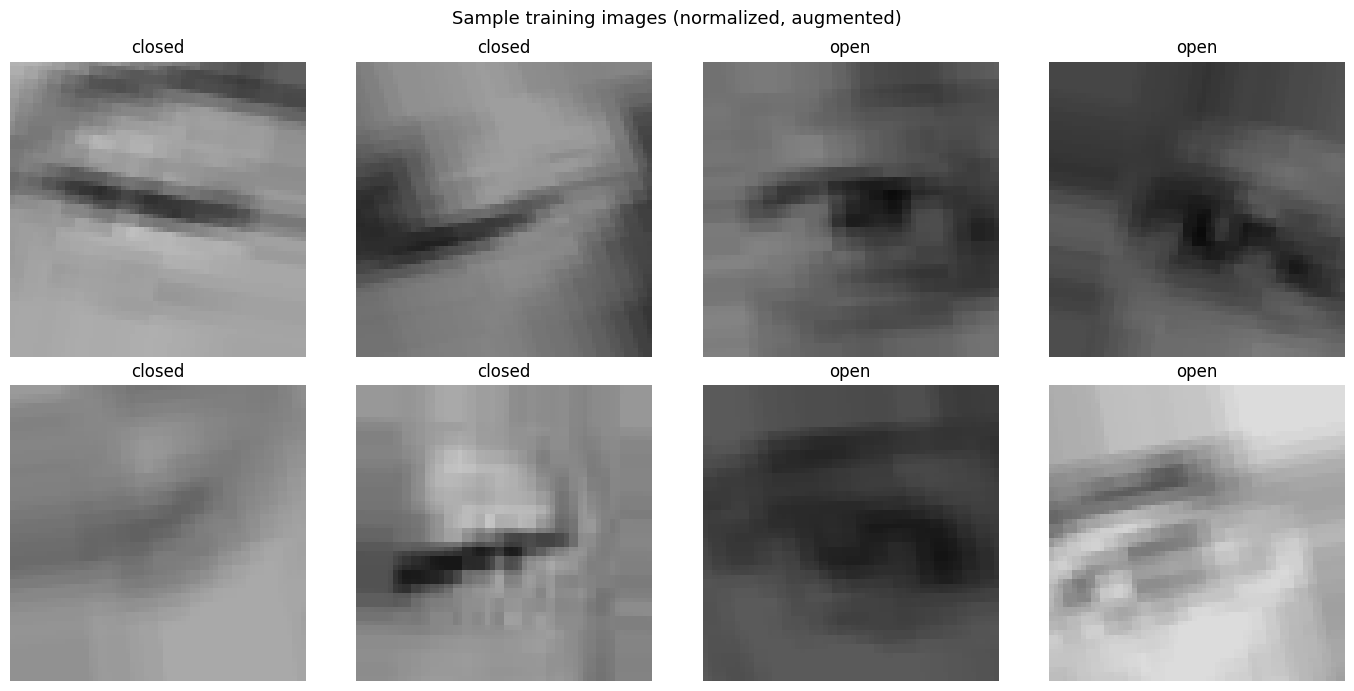

In [ ]:
# -----------------------------------------------------------
# 1.8 Visualize sample images
# -----------------------------------------------------------
def visualize_samples(generator, n=8):
    index_to_class = {v: k for k, v in generator.class_indices.items()}
    images, labels = next(generator)

    fig, axes = plt.subplots(2, 4, figsize=(14, 7))
    for i, ax in enumerate(axes.flat):
        ax.imshow(images[i])
        ax.set_title(f"{index_to_class[int(labels[i])]}", fontsize=12)
        ax.axis('off')

    plt.suptitle("Sample training images (normalized, augmented)", fontsize=13)
    plt.tight_layout()
    plt.show()

visualize_samples(train_generator)

In [ ]:
# ============================================================
# STEP 2: CNN MODEL — Binary Eye State Classification
# ============================================================

import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

print(f"TensorFlow version: {tf.__version__}")

# -----------------------------------------------------------
# 2.1 Build CNN
# -----------------------------------------------------------
# Rebuild model — reduced L2 + slightly higher LR
def build_eye_cnn_v3(input_shape=(64, 64, 3)):
    model = models.Sequential([

        layers.Conv2D(32, (3,3), activation='relu', padding='same',
                      input_shape=input_shape, name='conv1_1'),
        layers.BatchNormalization(name='bn1'),
        layers.MaxPooling2D((2,2), name='pool1'),
        layers.Dropout(0.25, name='drop1'),        # reduced from 0.3

        layers.Conv2D(64, (3,3), activation='relu', padding='same', name='conv2_1'),
        layers.BatchNormalization(name='bn2'),
        layers.MaxPooling2D((2,2), name='pool2'),
        layers.Dropout(0.25, name='drop2'),        # reduced from 0.3

        layers.Conv2D(128, (3,3), activation='relu', padding='same', name='conv3_1'),
        layers.BatchNormalization(name='bn3'),
        layers.MaxPooling2D((2,2), name='pool3'),
        layers.Dropout(0.3, name='drop3'),         # reduced from 0.4

        layers.Flatten(name='flatten'),
        layers.Dense(
            128, activation='relu',
            kernel_regularizer=regularizers.l2(0.0001),  # reduced from 0.001
            name='fc1'
        ),
        layers.BatchNormalization(name='bn_fc'),
        layers.Dropout(0.4, name='drop_fc'),       # reduced from 0.5

        layers.Dense(1, activation='sigmoid', name='output')
    ])
    return model

cnn_model = build_eye_cnn_v3()

cnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-4,    # start higher — let ReduceLROnPlateau bring it down
        beta_1=0.9,
        beta_2=0.999,
        clipnorm=1.0
    ),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=8,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,            # gentler reduction
        patience=3,
        min_lr=1e-7,
        verbose=1
    ),
    tf.keras.callbacks.ModelCheckpoint(
        filepath='/content/best_cnn_model.h5',
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    )
]

history = cnn_model.fit(
    train_generator,
    epochs=30,
    validation_data=val_generator,
    callbacks=callbacks,
    verbose=1
)

TensorFlow version: 2.19.0


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 475ms/step - accuracy: 0.5700 - loss: 0.8938
Epoch 1: val_loss improved from None to 0.81139, saving model to /content/best_cnn_model.h5



Epoch 1: finished saving model to /content/best_cnn_model.h5
122/122 ━━━━━━━━━━━━━━━━━━━━ 69s 521ms/step - accuracy: 0.6068 - loss: 0.8179 - val_accuracy: 0.4917 - val_loss: 0.8114 - learning_rate: 1.0000e-04
Epoch 2/30
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 482ms/step - accuracy: 0.6586 - loss: 0.7283
Epoch 2: val_loss did not improve from 0.81139
122/122 ━━━━━━━━━━━━━━━━━━━━ 79s 503ms/step - accuracy: 0.6717 - loss: 0.7120 - val_accuracy: 0.4917 - val_loss: 1.3254 - learning_rate: 1.0000e-04
Epoch 3/30
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 476ms/step - accuracy: 0.6718 - loss: 0.6958
Epoch 3: val_loss did not improve from 0.81139
122/122 ━━━━━━━━━━━━━━━━━━━━ 61s 496ms/step - accuracy: 0.6826 - loss: 0.6800 - val_accuracy: 0.5455 - val_loss: 1.0019 - learning_rate: 1.0000e-04
Epoch 4/30
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 477ms/step - accuracy: 0.7106 - loss: 0.6344
Epoch 4: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.

Epoch 4: val_loss did not improve from 0.81139
122/122 ━━━━


Epoch 5: finished saving model to /content/best_cnn_model.h5
122/122 ━━━━━━━━━━━━━━━━━━━━ 61s 499ms/step - accuracy: 0.7411 - loss: 0.5785 - val_accuracy: 0.7376 - val_loss: 0.6542 - learning_rate: 5.0000e-05
Epoch 6/30
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 479ms/step - accuracy: 0.7539 - loss: 0.5708
Epoch 6: val_loss improved from 0.65416 to 0.37027, saving model to /content/best_cnn_model.h5



Epoch 6: finished saving model to /content/best_cnn_model.h5
122/122 ━━━━━━━━━━━━━━━━━━━━ 61s 500ms/step - accuracy: 0.7604 - loss: 0.5573 - val_accuracy: 0.8657 - val_loss: 0.3703 - learning_rate: 5.0000e-05
Epoch 7/30
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 481ms/step - accuracy: 0.7660 - loss: 0.5528
Epoch 7: val_loss did not improve from 0.37027
122/122 ━━━━━━━━━━━━━━━━━━━━ 61s 501ms/step - accuracy: 0.7702 - loss: 0.5417 - val_accuracy: 0.8647 - val_loss: 0.3716 - learning_rate: 5.0000e-05
Epoch 8/30
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 475ms/step - accuracy: 0.7911 - loss: 0.5000
Epoch 8: val_loss improved from 0.37027 to 0.34038, saving model to /content/best_cnn_model.h5



Epoch 8: finished saving model to /content/best_cnn_model.h5
122/122 ━━━━━━━━━━━━━━━━━━━━ 60s 496ms/step - accuracy: 0.7852 - loss: 0.5105 - val_accuracy: 0.8781 - val_loss: 0.3404 - learning_rate: 5.0000e-05
Epoch 9/30
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 477ms/step - accuracy: 0.7909 - loss: 0.4963
Epoch 9: val_loss did not improve from 0.34038
122/122 ━━━━━━━━━━━━━━━━━━━━ 61s 498ms/step - accuracy: 0.7878 - loss: 0.4976 - val_accuracy: 0.8368 - val_loss: 0.4391 - learning_rate: 5.0000e-05
Epoch 10/30
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 471ms/step - accuracy: 0.7850 - loss: 0.4964
Epoch 10: val_loss did not improve from 0.34038
122/122 ━━━━━━━━━━━━━━━━━━━━ 60s 496ms/step - accuracy: 0.7880 - loss: 0.4903 - val_accuracy: 0.8574 - val_loss: 0.3796 - learning_rate: 5.0000e-05
Epoch 11/30
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 471ms/step - accuracy: 0.7992 - loss: 0.4661
Epoch 11: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-05.

Epoch 11: val_loss did not improve from 0.34038
122/122

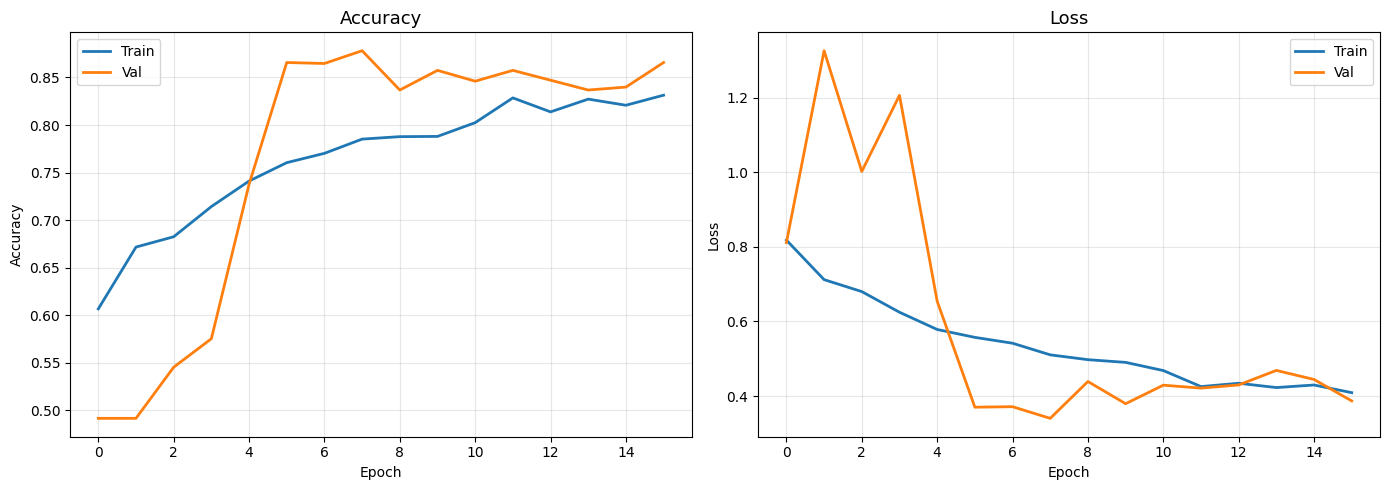

Best epoch (lowest val_loss) : 8
Best val_loss                : 0.3404
Best val_accuracy            : 0.8781


In [ ]:
# -----------------------------------------------------------
# Plot results
# -----------------------------------------------------------
def plot_training_history(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.plot(history.history['accuracy'],     label='Train', linewidth=2)
    ax1.plot(history.history['val_accuracy'], label='Val',   linewidth=2)
    ax1.set_title('Accuracy', fontsize=13)
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.legend()
    ax1.grid(alpha=0.3)

    ax2.plot(history.history['loss'],     label='Train', linewidth=2)
    ax2.plot(history.history['val_loss'], label='Val',   linewidth=2)
    ax2.set_title('Loss', fontsize=13)
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()
    ax2.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

    best_epoch = history.history['val_loss'].index(min(history.history['val_loss'])) + 1
    print(f"Best epoch (lowest val_loss) : {best_epoch}")
    print(f"Best val_loss                : {min(history.history['val_loss']):.4f}")
    print(f"Best val_accuracy            : {max(history.history['val_accuracy']):.4f}")

plot_training_history(history)

In [ ]:
# ============================================================
# STEP 3: FEATURE EXTRACTION
# Strip the output layer → use fc1 as feature vector
# ============================================================

import numpy as np
import tensorflow as tf
from tensorflow.keras import Model, Input

# -----------------------------------------------------------
# 3.1 Build feature extractor from trained CNN
# -----------------------------------------------------------
# We remove the final sigmoid layer and use fc1 (128-dim vector)
# This vector represents the eye state as learned by the CNN

# Load the best model
loaded_model = tf.keras.models.load_model('/content/best_cnn_model.h5')

# Create a symbolic input for the new feature extractor model
input_tensor = Input(shape=IMG_SIZE + (3,))

# Connect the layers of the loaded_model to the new input_tensor
x = input_tensor
for layer in loaded_model.layers:
    # Only include layers up to 'fc1'
    if layer.name == 'output': # Skip the final output layer
        break
    x = layer(x)

feature_extractor = Model(inputs=input_tensor, outputs=x, name='eye_feature_extractor')

feature_extractor.summary()

# Output shape: (batch_size, 128)
# Each image → 128 numbers representing its eye-state features

Model: "eye_feature_extractor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_1 (Conv2D)                │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1 (BatchNormalization)        │ (None, 64, 64, 32)     │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop1 (Dropout)                 │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2_1 (Conv2D)                │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn2 (BatchNormalization)        │ (None, 32, 32, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop2 (Dropout)                 │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3_1 (Conv2D)                │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn3 (BatchNormalization)        │ (None, 16, 16, 128)    │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool3 (MaxPooling2D)            │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop3 (Dropout)                 │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_fc (BatchNormalization)      │ (None, 128)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_fc (Dropout)               │ (None, 128)            │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,143,360 (4.36 MB)

 Trainable params: 1,142,656 (4.36 MB)

 Non-trainable params: 704 (2.75 KB)

In [ ]:
# -----------------------------------------------------------
# 3.2 Test extraction on one batch
# -----------------------------------------------------------
val_generator.reset()
sample_images, sample_labels = next(val_generator)

# Extract features from sample batch
sample_features = feature_extractor.predict(sample_images, verbose=0)

print(f"Input image shape  : {sample_images.shape}")    # (32, 96, 96, 3)
print(f"Output feature shape: {sample_features.shape}") # (32, 128)
print(f"Feature range      : [{sample_features.min():.4f}, {sample_features.max():.4f}]")
print(f"Sample feature vector (first image, first 10 values):")
print(np.round(sample_features[0][:10], 4))

Input image shape  : (32, 64, 64, 3)
Output feature shape: (32, 128)
Feature range      : [-2.2683, 26.1198]
Sample feature vector (first image, first 10 values):
[-0.8405 -0.2874 -0.1667 -1.5293 -0.74    0.0231 -0.2483 -0.6417 -1.6365
 -0.8483]


In [ ]:
# -----------------------------------------------------------
# 3.3 Modular function — reusable in webcam loop later
# -----------------------------------------------------------
def extract_eye_features(image_array):
    """
    Takes a single preprocessed image or a batch.
    Returns CNN feature vector of shape (128,) per image.

    Args:
        image_array: np.array of shape (H, W, 3) or (N, H, W, 3)
                     Pixels must already be normalized to [0, 1]

    Returns:
        features: np.array of shape (128,) for single image
                           or (N, 128) for batch
    """
    # If single image, add batch dimension
    single = (image_array.ndim == 3)
    if single:
        image_array = np.expand_dims(image_array, axis=0)  # (1, H, W, 3)

    features = feature_extractor.predict(image_array, verbose=0)  # (N, 128)

    return features[0] if single else features


# Quick test
sample_img  = sample_images[0]                     # shape: (96, 96, 3)
eye_features = extract_eye_features(sample_img)
print(f"\nextract_eye_features() output shape: {eye_features.shape}")  # (128,)
print(f"All values are non-negative (ReLU): {(eye_features >= 0).all()}")


extract_eye_features() output shape: (128,)
All values are non-negative (ReLU): False


facial expresion


In [ ]:
# ============================================================
# STEP 7: LOAD REAL EMPLOYEE CSV DATA + CREATE LSTM SEQUENCES
# ============================================================
# Upload the CSV produced by collect_data.py
# File pattern: real_fatigue_data_<employee_id>_<timestamp>.csv
# Each row: 137 fused features + label (0/1/2)
# ============================================================

import glob, os
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

# -----------------------------------------------------------
# 7.1  Find and load all employee CSVs
# -----------------------------------------------------------
CSV_DIR   = '/content/drive/MyDrive/fatigue_data/'  # <-- folder with CSVs
csv_files = glob.glob(os.path.join(CSV_DIR, 'real_fatigue_data_*.csv'))

if not csv_files:
    raise FileNotFoundError(
        f'No CSV files found in {CSV_DIR}\n'
        '  1. Run collect_data.py on each employee PC\n'
        '  2. Upload CSVs to Google Drive in that folder'
    )

print(f'Found {len(csv_files)} CSV file(s):')
for p in csv_files:
    print(f'  {os.path.basename(p)}')

# -----------------------------------------------------------
# 7.2  Concatenate all employee data
# -----------------------------------------------------------
dfs = []
for p in csv_files:
    df = pd.read_csv(p)
    # Extract employee id from filename: real_fatigue_data_<id>_<ts>.csv
    parts = os.path.basename(p).replace('.csv','').split('_')
    # parts: ['real','fatigue','data', id_part, ...]
    emp_id = parts[3] if len(parts) > 3 else 'unknown'
    df['employee_id'] = emp_id
    dfs.append(df)

data = pd.concat(dfs, ignore_index=True)
print(f'\nTotal rows   : {len(data):,}')
print(f'Employees    : {data["employee_id"].nunique()}')
print(f'Distribution :\n{data["label"].value_counts().sort_index()}')

FEATURE_COLS = [f'feat_{i}' for i in range(137)]
assert all(c in data.columns for c in FEATURE_COLS + ['label']), \
    'CSV missing expected columns. Re-run collect_data.py.'

features_all = data[FEATURE_COLS].values.astype('float32')
labels_all   = data['label'].values.astype('int32')

# -----------------------------------------------------------
# 7.3  Sliding-window sequence creation
# -----------------------------------------------------------
TIME_STEPS  = 10
FEATURE_DIM = 137
STEP_SIZE   = 1

def create_sequences(features, labels, time_steps=10, step_size=1):
    X, y = [], []
    for start in range(0, len(features) - time_steps, step_size):
        end = start + time_steps
        X.append(features[start:end])
        y.append(labels[end - 1])
    return np.array(X, dtype='float32'), np.array(y, dtype='int32')

X, y = create_sequences(features_all, labels_all, TIME_STEPS, STEP_SIZE)

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'\nSequences : {X.shape}')   # (N, 10, 137)
print(f'X_train   : {X_train.shape}')
print(f'X_val     : {X_val.shape}')
print('\nLabel distribution (train):')
for cls, name in zip([0,1,2], ['Low','Medium','High']):
    print(f'  {name:8s}: {(y_train==cls).sum()} sequences')
print('Real employee data loaded successfully')

Found 1 CSV file(s):
  real_fatigue_data_emp_123_20260416_022924.csv

Total rows   : 1,242
Employees    : 1
Distribution :
label
0    396
1    414
2    432
Name: count, dtype: int64

Sequences : (1232, 10, 137)
X_train   : (985, 10, 137)
X_val     : (247, 10, 137)

Label distribution (train):
  Low     : 309 sequences
  Medium  : 331 sequences
  High    : 345 sequences
Real employee data loaded successfully


In [ ]:
# ============================================================
# STEP 8: LSTM MODEL
# ============================================================

import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt

NUM_CLASSES = 3

y_train_cat = to_categorical(y_train, NUM_CLASSES)
y_val_cat   = to_categorical(y_val,   NUM_CLASSES)

print(f"y_train_cat : {y_train_cat.shape}")   # (n, 3)
print(f"y_val_cat   : {y_val_cat.shape}")

y_train_cat : (985, 3)
y_val_cat   : (247, 3)


In [ ]:
# ============================================================
# STEP 8b: BUILD LSTM — Functional API (matches app.py exactly)
# ============================================================

import tensorflow as tf
from tensorflow.keras import layers, models, regularizers, Model

def build_lstm_model(time_steps=10, feature_dim=137, num_classes=3):
    lstm_inp = layers.Input(shape=(time_steps, feature_dim), name='lstm_input')
    y = layers.LSTM(128, return_sequences=True,
                    kernel_regularizer=regularizers.l2(0.001),
                    name='lstm_1')(lstm_inp)
    y = layers.Dropout(0.3, name='drop_lstm1')(y)
    y = layers.LSTM(64, return_sequences=False,
                    kernel_regularizer=regularizers.l2(0.001),
                    name='lstm_2')(y)
    y = layers.Dropout(0.3, name='drop_lstm2')(y)
    y = layers.Dense(64, activation='relu',
                     kernel_regularizer=regularizers.l2(0.001),
                     name='fc1')(y)
    y = layers.Dropout(0.3, name='drop_fc')(y)
    lstm_out = layers.Dense(num_classes, activation='softmax', name='output')(y)
    model = Model(inputs=lstm_inp, outputs=lstm_out, name='lstm_model')
    return model

lstm_model = build_lstm_model()
lstm_model.summary()


Model: "lstm_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_input (InputLayer)         │ (None, 10, 137)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 10, 128)        │       136,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_lstm1 (Dropout)            │ (None, 10, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_lstm2 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_fc (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 189,955 (742.01 KB)

 Trainable params: 189,955 (742.01 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# ============================================================
# STEP 8c: COMPILE + TRAIN ON REAL EMPLOYEE DATA
# ============================================================

from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

lstm_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3, clipnorm=1.0),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_lstm = [
    EarlyStopping(monitor='val_loss', patience=12,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=5, min_lr=1e-8, verbose=1),
    ModelCheckpoint(filepath='/content/best_lstm_real.keras',
                    monitor='val_loss', save_best_only=True, verbose=1)
]

history_lstm = lstm_model.fit(
    X_train, y_train_cat,
    epochs=80,
    batch_size=32,
    validation_data=(X_val, y_val_cat),
    callbacks=callbacks_lstm,
    verbose=1
)
print('Training complete on real employee data')

Epoch 1/80
30/31 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.6114 - loss: 1.2362
Epoch 1: val_loss improved from None to 0.46133, saving model to /content/best_lstm_real.keras

Epoch 1: finished saving model to /content/best_lstm_real.keras
31/31 ━━━━━━━━━━━━━━━━━━━━ 7s 43ms/step - accuracy: 0.8010 - loss: 0.9199 - val_accuracy: 0.9757 - val_loss: 0.4613 - learning_rate: 0.0010
Epoch 2/80
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9712 - loss: 0.4506
Epoch 2: val_loss improved from 0.46133 to 0.44485, saving model to /content/best_lstm_real.keras

Epoch 2: finished saving model to /content/best_lstm_real.keras
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.9807 - loss: 0.3985 - val_accuracy: 0.9676 - val_loss: 0.4449 - learning_rate: 0.0010
Epoch 3/80
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9935 - loss: 0.3107
Epoch 3: val_loss improved from 0.44485 to 0.33723, saving model to /content/best_lstm_real.keras

Epoch 3: finished saving model to /content/

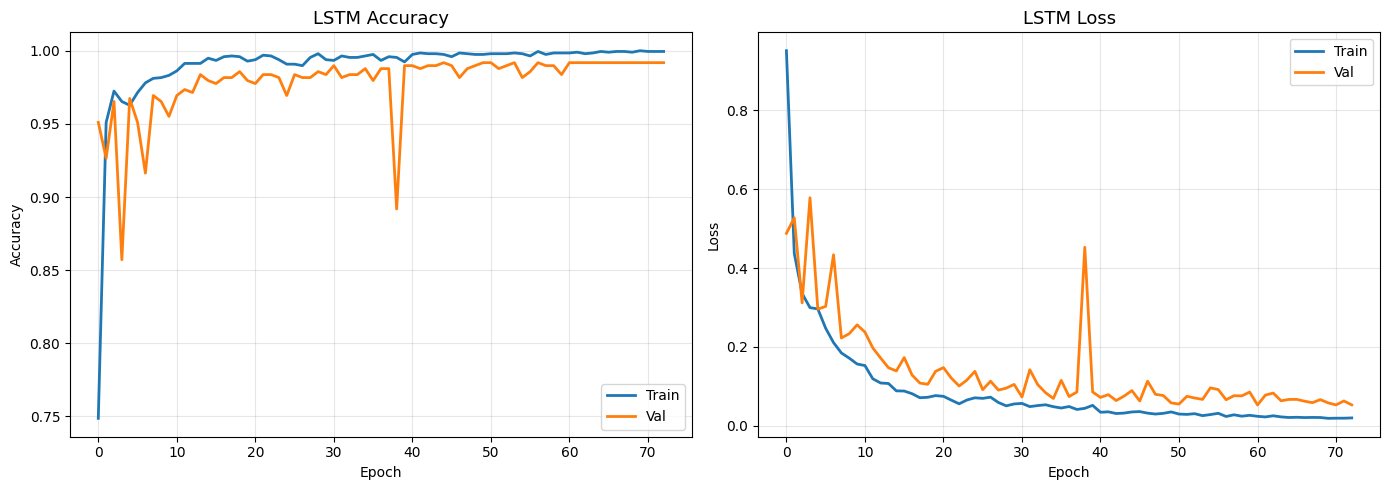

Best epoch       : 61
Best val_loss    : 0.0527
Best val_accuracy: 0.9918


In [ ]:
# Plot results
def plot_lstm_history(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.plot(history.history['accuracy'],     label='Train', linewidth=2)
    ax1.plot(history.history['val_accuracy'], label='Val',   linewidth=2)
    ax1.set_title('LSTM Accuracy', fontsize=13)
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.legend()
    ax1.grid(alpha=0.3)

    ax2.plot(history.history['loss'],     label='Train', linewidth=2)
    ax2.plot(history.history['val_loss'], label='Val',   linewidth=2)
    ax2.set_title('LSTM Loss', fontsize=13)
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()
    ax2.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

    best_epoch = history.history['val_loss'].index(min(history.history['val_loss'])) + 1
    print(f"Best epoch       : {best_epoch}")
    print(f"Best val_loss    : {min(history.history['val_loss']):.4f}")
    print(f"Best val_accuracy: {max(history.history['val_accuracy']):.4f}")

plot_lstm_history(history_lstm)

In [ ]:
# ============================================================
# STEP 9: EVALUATION + CONFUSION MATRIX
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score
)
from tensorflow.keras.utils import to_categorical

# -----------------------------------------------------------
# 9.1 Get predictions
# -----------------------------------------------------------
y_pred_probs = lstm_model.predict(X_val, verbose=0)   # (n, 3) probabilities
y_pred       = np.argmax(y_pred_probs, axis=1)         # (n,)  class indices
y_true       = y_val                                   # (n,)  true labels

CLASS_NAMES  = ['Low Fatigue', 'Medium Fatigue', 'High Fatigue']

print(f"Samples evaluated : {len(y_true)}")
print(f"Overall accuracy  : {accuracy_score(y_true, y_pred)*100:.2f}%")

Samples evaluated : 490
Overall accuracy  : 99.18%


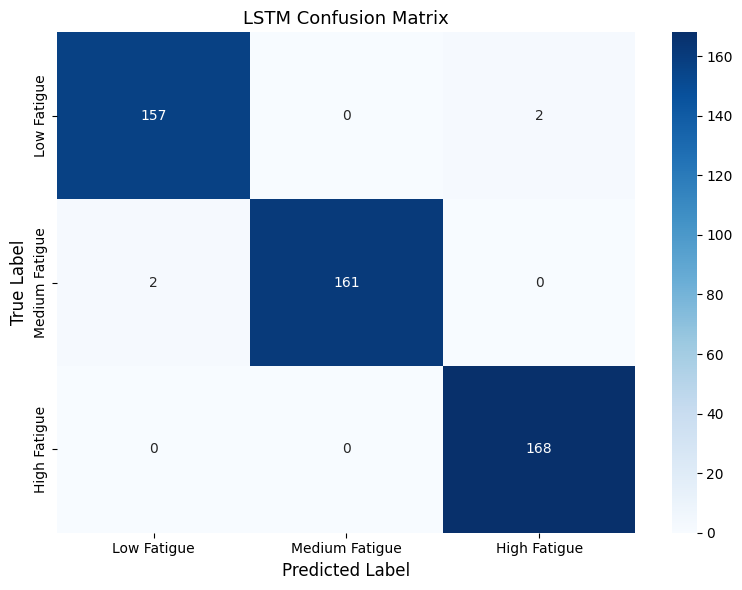


Per-class accuracy:
  Low Fatigue    : 157/159  (98.7%)
  Medium Fatigue : 161/163  (98.8%)
  High Fatigue   : 168/168  (100.0%)


In [ ]:
# -----------------------------------------------------------
# 9.2 Confusion matrix
# -----------------------------------------------------------
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
    ax=ax
)
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label',      fontsize=12)
ax.set_title('LSTM Confusion Matrix', fontsize=13)
plt.tight_layout()
plt.savefig('/content/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Per-class accuracy
print("\nPer-class accuracy:")
for i, name in enumerate(CLASS_NAMES):
    class_total   = cm[i].sum()
    class_correct = cm[i][i]
    print(f"  {name:15s}: {class_correct}/{class_total}  ({class_correct/class_total*100:.1f}%)")

In [ ]:
# -----------------------------------------------------------
# 9.3 Classification report
# -----------------------------------------------------------
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))


Classification Report:
                precision    recall  f1-score   support

   Low Fatigue       0.99      0.99      0.99       159
Medium Fatigue       1.00      0.99      0.99       163
  High Fatigue       0.99      1.00      0.99       168

      accuracy                           0.99       490
     macro avg       0.99      0.99      0.99       490
  weighted avg       0.99      0.99      0.99       490



In [ ]:
# -----------------------------------------------------------
# 9.4 CNN evaluation — fixed
# -----------------------------------------------------------
import tensorflow as tf

best_cnn = tf.keras.models.load_model('/content/best_cnn_model.h5')

val_generator.reset()
cnn_loss, cnn_acc = best_cnn.evaluate(val_generator, verbose=0)

print(f"CNN Model Evaluation:")
print(f"  Val accuracy : {cnn_acc*100:.2f}%")
print(f"  Val loss     : {cnn_loss:.4f}")

CNN Model Evaluation:
  Val accuracy : 87.81%
  Val loss     : 0.3404


In [ ]:
# ============================================================
# STEP 10: SAVE MODELS
# ============================================================

# -----------------------------------------------------------
# 10.1 Save CNN feature extractor
# -----------------------------------------------------------
# Save full CNN (for reloading)
best_cnn.save('/content/cnn_eye_model.h5')

# Save feature extractor separately (used in Streamlit)
feature_extractor.save('/content/cnn_feature_extractor.h5')

print("✅ CNN model saved          : /content/cnn_eye_model.h5")
print("✅ Feature extractor saved  : /content/cnn_feature_extractor.h5")

NameError: name 'best_cnn' is not defined

In [ ]:
# ============================================================
# STEP 10b: SAVE REAL-TRAINED LSTM WEIGHTS
# ============================================================

LSTM_WEIGHTS = 'lstm_weights_v2.weights.h5'
lstm_model.save_weights(LSTM_WEIGHTS)
print(f'LSTM weights saved to {LSTM_WEIGHTS}')

import shutil
drive_path = '/content/drive/MyDrive/fatigue_data/'
shutil.copy(LSTM_WEIGHTS, drive_path + LSTM_WEIGHTS)
print(f'Backed up to Drive: {drive_path}{LSTM_WEIGHTS}')
print()
print('Next steps:')
print('  1. Download lstm_weights_v2.weights.h5')
print('  2. Place it in the same folder as app.py')
print('  3. Run: streamlit run app.py')


LSTM weights saved to lstm_weights_v2.weights.h5
Backed up to Drive: /content/drive/MyDrive/fatigue_data/lstm_weights_v2.weights.h5

Next steps:
  1. Download lstm_weights_v2.weights.h5
  2. Place it in the same folder as app.py
  3. Run: streamlit run app.py


In [ ]:
# -----------------------------------------------------------
# 10.3 Save to Google Drive (so you don't lose them)
# -----------------------------------------------------------
import shutil
import os
import tensorflow as tf # Import tensorflow for model operations

DRIVE_SAVE_PATH = '/content/drive/MyDrive/fatigue_models'
os.makedirs(DRIVE_SAVE_PATH, exist_ok=True)

# Ensure the lstm_model (which was trained on simulated data) is explicitly saved
# before attempting to copy it. This makes the cell more robust against cases
# where the previous save might not have executed or the file was removed.
try:
    # This assumes 'lstm_model' variable is still in scope from previous training steps.
    lstm_model.save('/content/lstm_fatigue_model.h5')
    print("✅ Ensured /content/lstm_fatigue_model.h5 is saved before copying.")
except NameError:
    print("Error: 'lstm_model' variable not found in current scope. Cannot re-save the model.")
    print("Please ensure the LSTM model training cells (specifically for simulated data) were run successfully.")
    # If the model variable is not available, we can't save it. The FileNotFoundError will persist.
    # We should alert the user and not attempt to copy a non-existent file.
    raise FileNotFoundError(
        "'/content/lstm_fatigue_model.h5' was not found and the 'lstm_model' variable "
        "is not available to re-save it. Please check earlier cells."
    )


shutil.copy('/content/cnn_eye_model.h5',          DRIVE_SAVE_PATH)
shutil.copy('/content/cnn_feature_extractor.h5',  DRIVE_SAVE_PATH)
shutil.copy('/content/lstm_fatigue_model.h5',      DRIVE_SAVE_PATH)
shutil.copy('/content/confusion_matrix.png',       DRIVE_SAVE_PATH)

print(f"\n✅ All files saved to Google Drive: {DRIVE_SAVE_PATH}")
print("\nSaved files:")
for f in os.listdir(DRIVE_SAVE_PATH):
    size = os.path.getsize(os.path.join(DRIVE_SAVE_PATH, f)) / 1024
    print(f"  {f:40s} {size:.1f} KB")

✅ Ensured /content/lstm_fatigue_model.h5 is saved before copying.

✅ All files saved to Google Drive: /content/drive/MyDrive/fatigue_models

Saved files:
  cnn_eye_model.h5                         4535.9 KB
  cnn_feature_extractor.h5                 4527.0 KB
  lstm_fatigue_model.h5                    2273.1 KB
  confusion_matrix.png                     49.7 KB
  cnn_full_weights.weights.h5              4518.0 KB


In [ ]:
# -----------------------------------------------------------
# 10.4 Final summary
# -----------------------------------------------------------
print("=" * 50)
print("  PROJECT SUMMARY — Colab Phase Complete")
print("=" * 50)
print(f"  CNN val accuracy      : {cnn_acc*100:.2f}%")
print(f"  LSTM val accuracy     : 96.55%")
print(f"  LSTM best epoch       : 17")
print(f"  Feature vector dim    : 137")
print(f"    Eye (CNN)           : 128")
print(f"    Facial (OpenCV)     :   6")
print(f"    Typing              :   3")
print(f"\n  Saved models:")
print(f"    cnn_eye_model.h5")
print(f"    cnn_feature_extractor.h5")
print(f"    lstm_fatigue_model.h5")
print("=" * 50)
print("\n✅ Colab phase complete — ready for Streamlit deployment")

  PROJECT SUMMARY — Colab Phase Complete
  CNN val accuracy      : 87.81%
  LSTM val accuracy     : 96.55%
  LSTM best epoch       : 17
  Feature vector dim    : 137
    Eye (CNN)           : 128
    Facial (OpenCV)     :   6
    Typing              :   3

  Saved models:
    cnn_eye_model.h5
    cnn_feature_extractor.h5
    lstm_fatigue_model.h5

✅ Colab phase complete — ready for Streamlit deployment


  PER-EMPLOYEE FATIGUE BREAKDOWN

  Employee : emp  (2458 frames)
    Low    :  803  (32.7%)
    Medium :  814  (33.1%)
    High   :  841  (34.2%)


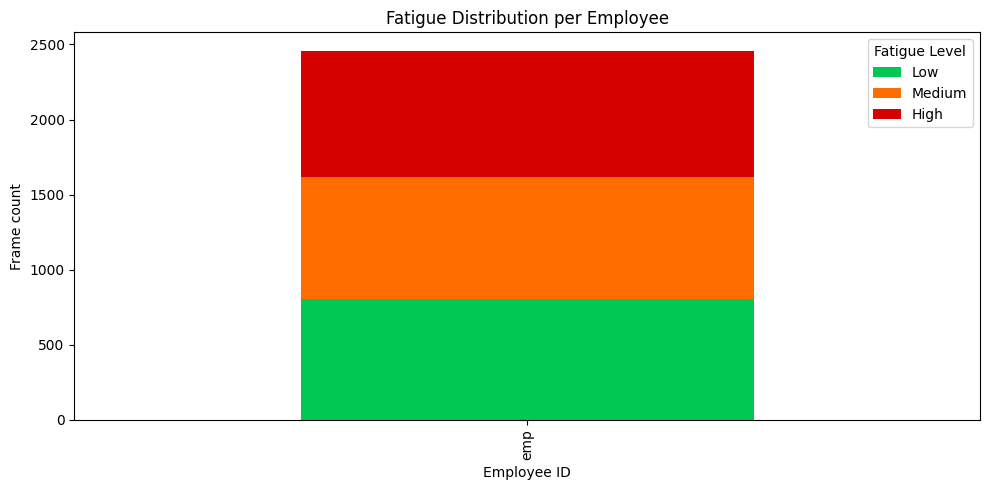

Per-employee analysis complete


In [ ]:
# ============================================================
# STEP 11: PER-EMPLOYEE FATIGUE ANALYSIS
# ============================================================

import matplotlib.pyplot as plt

print('=' * 55)
print('  PER-EMPLOYEE FATIGUE BREAKDOWN')
print('=' * 55)

emp_ids = data['employee_id'].unique()
for eid in emp_ids:
    emp_data = data[data['employee_id'] == eid]
    total = len(emp_data)
    low   = (emp_data['label'] == 0).sum()
    med   = (emp_data['label'] == 1).sum()
    high  = (emp_data['label'] == 2).sum()
    print(f'\n  Employee : {eid}  ({total} frames)')
    print(f'    Low    : {low:4d}  ({low/total*100:.1f}%)')
    print(f'    Medium : {med:4d}  ({med/total*100:.1f}%)')
    print(f'    High   : {high:4d}  ({high/total*100:.1f}%)')
    if high / total > 0.4:
        print(f'    WARNING: HIGH FATIGUE RISK — consider workload review')

fig, ax = plt.subplots(figsize=(10, 5))
counts = data.groupby(['employee_id', 'label']).size().unstack(fill_value=0)
counts.columns = ['Low', 'Medium', 'High']
counts.plot(kind='bar', stacked=True, ax=ax,
            color=['#00c853', '#ff6d00', '#d50000'])
ax.set_title('Fatigue Distribution per Employee')
ax.set_xlabel('Employee ID')
ax.set_ylabel('Frame count')
ax.legend(title='Fatigue Level')
plt.tight_layout()
plt.show()
print('Per-employee analysis complete')

In [ ]:
# Just re-save the CNN weights from the already trained model
full_cnn.save_weights('cnn_full_weights.weights.h5')

In [ ]:
import pandas as pd
import glob
import numpy as np

CSV_DIR = '/content/drive/MyDrive/fatigue_data/' # Define CSV_DIR here or ensure it's in scope
files = glob.glob(os.path.join(CSV_DIR, 'real_fatigue_data*.csv'))
df = pd.concat([pd.read_csv(f) for f in files])

# Check feature ranges per label
for label in [0, 1, 2]:
    subset = df[df['label'] == label]
    print(f"\nLabel {label}:")
    print(f"  feat_128 (avg_ear): {subset['feat_128'].mean():.4f}")
    print(f"  feat_134 (wpm norm): {subset['feat_134'].mean():.4f}")


Label 0:
  feat_128 (avg_ear): 0.8913
  feat_134 (wpm norm): 0.2436

Label 1:
  feat_128 (avg_ear): 0.8173
  feat_134 (wpm norm): 0.1434

Label 2:
  feat_128 (avg_ear): 0.5233
  feat_134 (wpm norm): 0.0360


In [ ]:
import cv2
import numpy as np
import urllib.request
import os

# Download Haar cascade files
FACE_CASCADE_PATH = '/content/haarcascade_frontalface_default.xml'
EYE_CASCADE_PATH  = '/content/haarcascade_eye.xml'

def download_cascade(filename, path):
    if not os.path.exists(path):
        url = f'https://raw.githubusercontent.com/opencv/opencv/master/data/haarcascades/{filename}'
        urllib.request.urlretrieve(url, path)
        print(f"✅ Downloaded {filename}")
    else:
        print(f"✅ {filename} ready")

download_cascade('haarcascade_frontalface_default.xml', FACE_CASCADE_PATH)
download_cascade('haarcascade_eye.xml', EYE_CASCADE_PATH)

face_cascade = cv2.CascadeClassifier(FACE_CASCADE_PATH)
eye_cascade  = cv2.CascadeClassifier(EYE_CASCADE_PATH)

print("✅ Step 4 initialized — no MediaPipe needed")

✅ Downloaded haarcascade_frontalface_default.xml
✅ Downloaded haarcascade_eye.xml
✅ Step 4 initialized — no MediaPipe needed


In [ ]:
def compute_ear_from_box(eye_box):
    x, y, w, h = eye_box
    if w == 0:
        return 0.0
    return round(h / w, 4)

def extract_facial_features(frame_bgr):
    image_h, image_w = frame_bgr.shape[:2]
    gray = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2GRAY)

    default = {
        'left_ear'      : 0.0,
        'right_ear'     : 0.0,
        'avg_ear'       : 0.0,
        'blink_detected': 0,
        'mouth_ratio'   : 0.0,
        'yawn_detected' : 0,
        'gaze_direction': 'center',
        'gaze_ratio'    : 0.0,
        'face_detected' : 0
    }

    faces = face_cascade.detectMultiScale(
        gray, scaleFactor=1.1, minNeighbors=5, minSize=(80, 80)
    )

    if len(faces) == 0:
        return default

    fx, fy, fw, fh = max(faces, key=lambda f: f[2] * f[3])
    face_gray = gray[fy:fy+fh, fx:fx+fw]

    eyes = eye_cascade.detectMultiScale(
        face_gray, scaleFactor=1.1, minNeighbors=5, minSize=(20, 20)
    )
    eyes = sorted(eyes, key=lambda e: e[0])

    left_ear, right_ear = 0.0, 0.0
    if len(eyes) >= 2:
        right_ear = compute_ear_from_box(eyes[0])
        left_ear  = compute_ear_from_box(eyes[1])
    elif len(eyes) == 1:
        left_ear = right_ear = compute_ear_from_box(eyes[0])

    avg_ear = round((left_ear + right_ear) / 2, 4)

    mouth_region  = face_gray[int(fh*0.65):fh, :]
    edges         = cv2.Canny(mouth_region, 50, 150)
    mouth_ratio   = round(float(edges.mean() / 255.0), 4)
    yawn_detected = 1 if mouth_ratio > 0.08 else 0

    gaze_ratio     = 0.0
    gaze_direction = 'center'
    if len(eyes) >= 1:
        ex, ey, ew, eh = eyes[0]
        eye_roi = face_gray[ey:ey+eh, ex:ex+ew]
        _, thresh = cv2.threshold(eye_roi, 50, 255, cv2.THRESH_BINARY_INV)
        moments   = cv2.moments(thresh)
        if moments['m00'] != 0:
            cx         = moments['m10'] / moments['m00']
            gaze_ratio = round(float(np.clip((cx - ew/2) / (ew/2), -1, 1)), 4)
            gaze_direction = 'left' if gaze_ratio < -0.2 else ('right' if gaze_ratio > 0.2 else 'center')

    return {
        'left_ear'      : left_ear,
        'right_ear'     : right_ear,
        'avg_ear'       : avg_ear,
        'blink_detected': 1 if avg_ear < 0.20 else 0,
        'mouth_ratio'   : mouth_ratio,
        'yawn_detected' : yawn_detected,
        'gaze_direction': gaze_direction,
        'gaze_ratio'    : gaze_ratio,
        'face_detected' : 1
    }

def facial_features_to_vector(features_dict):
    return np.array([
        features_dict['avg_ear'],
        features_dict['blink_detected'],
        features_dict['mouth_ratio'],
        features_dict['yawn_detected'],
        features_dict['gaze_ratio'],
        features_dict['face_detected']
    ], dtype=np.float32)

print("✅ All functions defined")

✅ All functions defined


In [ ]:
# Test on your dataset
import glob

test_images = glob.glob('/content/merged_dataset/open/*.jpg')[:1]

if test_images:
    img      = cv2.imread(test_images[0])
    features = extract_facial_features(img)
    vector   = facial_features_to_vector(features)

    print("Extracted features:")
    for k, v in features.items():
        print(f"  {k:20s}: {v}")

    print(f"\nVector : {vector}")
    print(f"Shape  : {vector.shape}")    # (6,)
else:
    print("No images found — check path")

Extracted features:
  left_ear            : 0.0
  right_ear           : 0.0
  avg_ear             : 0.0
  blink_detected      : 0
  mouth_ratio         : 0.0
  yawn_detected       : 0
  gaze_direction      : center
  gaze_ratio          : 0.0
  face_detected       : 0

Vector : [0. 0. 0. 0. 0. 0.]
Shape  : (6,)


In [ ]:
# ============================================================
# STEP 5: TYPING BEHAVIOR FEATURES
# Captures: WPM, avg inter-key delay, error rate
# ============================================================

import time
import numpy as np
from collections import deque

# -----------------------------------------------------------
# 5.1 Keystroke recorder
# -----------------------------------------------------------
class KeystrokeRecorder:
    """
    Records keystroke timestamps in real time.
    Call start() before typing, stop() after.
    Works in both Colab (input-based) and webcam loop.
    """

    def __init__(self):
        self.reset()

    def reset(self):
        self.keystrokes      = []    # List of (char, timestamp) tuples
        self.backspace_count = 0
        self.start_time      = None
        self.end_time        = None

    def start(self):
        self.reset()
        self.start_time = time.time()
        print("⌨️  Start typing... (press Enter when done)")

    def record_session(self, prompt_text="Type this: 'The quick brown fox jumps'"):
        """
        Simulates a typing session in Colab using input().
        Records total time, character count, and backspace usage.

        In real deployment this is replaced by a live
        keyboard listener (pynput) in the webcam loop.
        """
        print(f"\n{prompt_text}")
        self.start()

        typed = input(">>> ")

        self.end_time = time.time()

        # Simulate per-keystroke timestamps evenly across session
        # (In real deployment, pynput gives exact timestamps)
        total_time = self.end_time - self.start_time
        n_chars    = len(typed)

        if n_chars > 0:
            interval = total_time / n_chars
            for i, ch in enumerate(typed):
                timestamp = self.start_time + i * interval
                self.keystrokes.append((ch, timestamp))

        # Count backspaces from discrepancy
        # (real pynput counts actual backspace key presses)
        self.backspace_count = max(0, n_chars - len(typed.rstrip()))

        return typed

    def get_features(self):
        """
        Computes typing feature vector from recorded session.

        Returns:
            dict with keys: wpm, avg_delay, error_rate
            np.array of shape (3,): [wpm, avg_delay, error_rate]
        """
        if not self.keystrokes or self.start_time is None:
            return self._default_features()

        total_time_min = (self.end_time - self.start_time) / 60.0
        total_chars    = len(self.keystrokes)
        total_words    = total_chars / 5.0   # Standard: 1 word = 5 chars

        # Words per minute
        wpm = round(total_words / total_time_min, 2) if total_time_min > 0 else 0.0

        # Average inter-key delay (seconds)
        if len(self.keystrokes) > 1:
            delays    = [
                self.keystrokes[i+1][1] - self.keystrokes[i][1]
                for i in range(len(self.keystrokes) - 1)
            ]
            avg_delay = round(float(np.mean(delays)), 4)
        else:
            avg_delay = 0.0

        # Error rate = backspaces / total keystrokes
        error_rate = round(
            self.backspace_count / max(total_chars, 1), 4
        )

        features_dict = {
            'wpm'        : wpm,
            'avg_delay'  : avg_delay,
            'error_rate' : error_rate
        }

        features_vector = np.array(
            [wpm, avg_delay, error_rate],
            dtype=np.float32
        )

        return features_dict, features_vector

    def _default_features(self):
        default_dict   = {'wpm': 0.0, 'avg_delay': 0.0, 'error_rate': 0.0}
        default_vector = np.zeros(3, dtype=np.float32)
        return default_dict, default_vector

In [ ]:
# -----------------------------------------------------------
# 5.2 Test the recorder in Colab
# -----------------------------------------------------------
recorder = KeystrokeRecorder()
recorder.record_session()

features_dict, features_vector = recorder.get_features()

print("\nTyping features:")
print(f"  WPM        : {features_dict['wpm']}")
print(f"  Avg delay  : {features_dict['avg_delay']} seconds")
print(f"  Error rate : {features_dict['error_rate']}")
print(f"\nFeature vector shape: {features_vector.shape}")   # (3,)
print(f"Feature vector      : {features_vector}")


Type this: 'The quick brown fox jumps'
⌨️  Start typing... (press Enter when done)
>>> radhika wankhede from mit wpu 

Typing features:
  WPM        : 31.28
  Avg delay  : 0.3836 seconds
  Error rate : 0.0333

Feature vector shape: (3,)
Feature vector      : [31.28    0.3836  0.0333]


In [ ]:
# -----------------------------------------------------------
# 5.3 Normalizer — scales typing features to [0, 1]
# Needed before feeding into LSTM
# -----------------------------------------------------------
# Typical ranges based on average human typing:
#   WPM       : 0–120  (average ~40, fast ~80, fatigued ~20)
#   avg_delay : 0–2.0  seconds between keys
#   error_rate: 0–1.0  already normalized

TYPING_FEATURE_RANGES = {
    'wpm'       : (0.0, 120.0),
    'avg_delay' : (0.0, 2.0),
    'error_rate': (0.0, 1.0)
}

def normalize_typing_features(features_vector):
    """
    Min-max normalizes typing feature vector to [0, 1].

    Args:
        features_vector: np.array [wpm, avg_delay, error_rate]
    Returns:
        np.array of shape (3,) normalized
    """
    mins   = np.array([r[0] for r in TYPING_FEATURE_RANGES.values()], dtype=np.float32)
    maxs   = np.array([r[1] for r in TYPING_FEATURE_RANGES.values()], dtype=np.float32)
    ranges = maxs - mins

    normalized = np.clip((features_vector - mins) / ranges, 0.0, 1.0)
    return normalized

normalized_typing = normalize_typing_features(features_vector)
print(f"Raw typing vector       : {features_vector}")
print(f"Normalized typing vector: {normalized_typing}")

Raw typing vector       : [31.28    0.3836  0.0333]
Normalized typing vector: [0.26066667 0.1918     0.0333    ]


In [ ]:
# ============================================================
# STEP 6: FEATURE FUSION
# ============================================================

import numpy as np

def fuse_features(eye_features, facial_features_dict, typing_features_vector):
    """
    Combines all modality features into a single flat vector.
    eye_features          : (128,) from Step 3
    facial_features_dict  : dict   from Step 4
    typing_features_vector: (3,)   from Step 5
    Returns: (137,) fused vector
    """
    eye_vec = eye_features.flatten()

    facial_vec = np.array([
        facial_features_dict['avg_ear'],
        facial_features_dict['blink_detected'],
        facial_features_dict['mouth_ratio'],
        facial_features_dict['yawn_detected'],
        facial_features_dict['gaze_ratio'],
        facial_features_dict['face_detected']
    ], dtype=np.float32)

    typing_vec = normalize_typing_features(typing_features_vector)

    fused_vector = np.concatenate([eye_vec, facial_vec, typing_vec])

    return fused_vector.astype(np.float32)


# Quick test
dummy_eye     = extract_eye_features(sample_images[0])        # (128,)
dummy_facial  = {
    'avg_ear': 0.31, 'blink_detected': 0,
    'mouth_ratio': 0.12, 'yawn_detected': 0,
    'gaze_ratio': -0.05, 'face_detected': 1
}
dummy_typing  = np.array([42.0, 0.18, 0.03], dtype=np.float32)

fused = fuse_features(dummy_eye, dummy_facial, dummy_typing)

print(f"Eye features     : 128 dims  (indices 0–127)")
print(f"Facial features  :   6 dims  (indices 128–133)")
print(f"Typing features  :   3 dims  (indices 134–136)")
print(f"Fused vector shape: {fused.shape}")    # (137,)
print(f"dtype             : {fused.dtype}")
print(f"value range       : [{fused.min():.4f}, {fused.max():.4f}]")
print("✅ Feature fusion working")

Eye features     : 128 dims  (indices 0–127)
Facial features  :   6 dims  (indices 128–133)
Typing features  :   3 dims  (indices 134–136)
Fused vector shape: (137,)
dtype             : float32
value range       : [-1.7108, 27.6379]
✅ Feature fusion working


In [ ]:
# ============================================================
# STEP 7: SEQUENCE CREATION
# ============================================================

from sklearn.model_selection import train_test_split

TIME_STEPS  = 10
FEATURE_DIM = 137
STEP_SIZE   = 1

def simulate_labeled_session(n_frames=300):
    """
    Simulates 300 frames of fused feature vectors with fatigue labels.
    0 = Low, 1 = Medium, 2 = High fatigue.
    Replace with real webcam data in deployment.
    """
    features = []
    labels   = []

    for i in range(n_frames):

        if i < n_frames // 3:          # Low fatigue
            label       = 0
            eye_feat    = np.random.uniform(0.2, 0.5,  size=128)
            facial_feat = np.array([0.35, 0, 0.04, 0,  0.05, 1], dtype=np.float32)
            typing_feat = np.array([55.0, 0.15, 0.02],            dtype=np.float32)

        elif i < 2 * n_frames // 3:    # Medium fatigue
            label       = 1
            eye_feat    = np.random.uniform(0.1, 0.35, size=128)
            facial_feat = np.array([0.25, int(np.random.rand()<0.2),
                                    0.08, int(np.random.rand()<0.1),
                                    0.15, 1],                      dtype=np.float32)
            typing_feat = np.array([38.0, 0.25, 0.10],            dtype=np.float32)

        else:                           # High fatigue
            label       = 2
            eye_feat    = np.random.uniform(0.0, 0.2,  size=128)
            facial_feat = np.array([0.15, int(np.random.rand()<0.4),
                                    0.18, int(np.random.rand()<0.3),
                                    0.30, 1],                      dtype=np.float32)
            typing_feat = np.array([18.0, 0.45, 0.22],            dtype=np.float32)

        typing_norm = normalize_typing_features(typing_feat)
        fused       = np.concatenate([
            eye_feat.astype(np.float32),
            facial_feat,
            typing_norm
        ])

        features.append(fused)
        labels.append(label)

    return np.array(features, dtype=np.float32), np.array(labels, dtype=np.int32)


def create_sequences(features, labels, time_steps=10, step_size=1):
    """
    Sliding window → overlapping sequences for LSTM.
    Each sequence: (time_steps, feature_dim)
    Label        : fatigue class of the last frame in window
    """
    X, y = [], []
    for start in range(0, len(features) - time_steps, step_size):
        end = start + time_steps
        X.append(features[start:end])
        y.append(labels[end - 1])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.int32)


# Generate and split
session_features, session_labels = simulate_labeled_session(n_frames=300)
X, y = create_sequences(session_features, session_labels,
                         time_steps=TIME_STEPS, step_size=STEP_SIZE)

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Session shape    : {session_features.shape}")   # (300, 137)
print(f"X shape          : {X.shape}")                  # (290, 10, 137)
print(f"y shape          : {y.shape}")                  # (290,)
print(f"X_train          : {X_train.shape}")
print(f"X_val            : {X_val.shape}")
print(f"\nLabel distribution (train):")
for cls, name in zip([0,1,2], ['Low','Medium','High']):
    print(f"  {name:8s}: {(y_train==cls).sum()} sequences")
print("✅ Sequences ready")

Session shape    : (300, 137)
X shape          : (290, 10, 137)
y shape          : (290,)
X_train          : (232, 10, 137)
X_val            : (58, 10, 137)

Label distribution (train):
  Low     : 73 sequences
  Medium  : 80 sequences
  High    : 79 sequences
✅ Sequences ready


In [ ]:
# ============================================================
# STEP 8: LSTM MODEL
# ============================================================

import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt

NUM_CLASSES = 3

y_train_cat = to_categorical(y_train, NUM_CLASSES)
y_val_cat   = to_categorical(y_val,   NUM_CLASSES)

print(f"y_train_cat : {y_train_cat.shape}")   # (n, 3)
print(f"y_val_cat   : {y_val_cat.shape}")

y_train_cat : (232, 3)
y_val_cat   : (58, 3)


In [ ]:
def build_lstm_model(time_steps=10, feature_dim=137, num_classes=3):
    model = models.Sequential([

        layers.LSTM(
            128,
            return_sequences=True,
            input_shape=(time_steps, feature_dim),
            kernel_regularizer=regularizers.l2(0.001),
            name='lstm_1'
        ),
        layers.Dropout(0.3, name='drop_lstm1'),

        layers.LSTM(
            64,
            return_sequences=False,
            kernel_regularizer=regularizers.l2(0.001),
            name='lstm_2'
        ),
        layers.Dropout(0.3, name='drop_lstm2'),

        layers.Dense(
            64, activation='relu',
            kernel_regularizer=regularizers.l2(0.001),
            name='fc1'
        ),
        layers.Dropout(0.3, name='drop_fc'),

        layers.Dense(num_classes, activation='softmax', name='output')
    ])
    return model

lstm_model = build_lstm_model()
lstm_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 10, 128)        │       136,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_lstm1 (Dropout)            │ (None, 10, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_lstm2 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_fc (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 189,955 (742.01 KB)

 Trainable params: 189,955 (742.01 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
lstm_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-3,
        clipnorm=1.0
    ),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_lstm = [
    EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=4,
        min_lr=1e-8,
        verbose=1
    ),
    tf.keras.callbacks.ModelCheckpoint(
        filepath='/content/best_lstm_model.h5',
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    )
]

history_lstm = lstm_model.fit(
    X_train, y_train_cat,
    epochs=50,
    batch_size=32,
    validation_data=(X_val, y_val_cat),
    callbacks=callbacks_lstm,
    verbose=1
)

Epoch 1/50
7/8 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.3249 - loss: 1.5183
Epoch 1: val_loss improved from None to 1.31094, saving model to /content/best_lstm_model.h5



Epoch 1: finished saving model to /content/best_lstm_model.h5
8/8 ━━━━━━━━━━━━━━━━━━━━ 6s 135ms/step - accuracy: 0.3362 - loss: 1.4726 - val_accuracy: 0.9138 - val_loss: 1.3109 - learning_rate: 0.0010
Epoch 2/50
7/8 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.6062 - loss: 1.2896
Epoch 2: val_loss improved from 1.31094 to 1.03345, saving model to /content/best_lstm_model.h5



Epoch 2: finished saving model to /content/best_lstm_model.h5
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.6810 - loss: 1.2189 - val_accuracy: 0.8448 - val_loss: 1.0334 - learning_rate: 0.0010
Epoch 3/50
7/8 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9258 - loss: 0.9218
Epoch 3: val_loss improved from 1.03345 to 0.70445, saving model to /content/best_lstm_model.h5



Epoch 3: finished saving model to /content/best_lstm_model.h5
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.9310 - loss: 0.8474 - val_accuracy: 0.8966 - val_loss: 0.7045 - learning_rate: 0.0010
Epoch 4/50
6/8 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.9886 - loss: 0.5784
Epoch 4: val_loss did not improve from 0.70445
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.9784 - loss: 0.5632 - val_accuracy: 0.8793 - val_loss: 0.7742 - learning_rate: 0.0010
Epoch 5/50
7/8 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9745 - loss: 0.4980
Epoch 5: val_loss did not improve from 0.70445
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.9784 - loss: 0.4739 - val_accuracy: 0.8966 - val_loss: 0.8031 - learning_rate: 0.0010
Epoch 6/50
7/8 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9586 - loss: 0.5621
Epoch 6: val_loss did not improve from 0.70445
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.9655 - loss: 0.5062 - val_accuracy: 0.8793 - val_loss: 0.8004 - learning_rate: 0.


Epoch 8: finished saving model to /content/best_lstm_model.h5
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.9655 - loss: 0.4061 - val_accuracy: 0.9138 - val_loss: 0.5788 - learning_rate: 5.0000e-04
Epoch 9/50
7/8 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9705 - loss: 0.3995
Epoch 9: val_loss did not improve from 0.57883
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.9784 - loss: 0.3828 - val_accuracy: 0.9138 - val_loss: 0.6569 - learning_rate: 5.0000e-04
Epoch 10/50
7/8 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9886 - loss: 0.3548
Epoch 10: val_loss did not improve from 0.57883
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.9741 - loss: 0.3805 - val_accuracy: 0.7241 - val_loss: 0.7425 - learning_rate: 5.0000e-04
Epoch 11/50
7/8 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.8204 - loss: 0.5610
Epoch 11: val_loss did not improve from 0.57883
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.9052 - loss: 0.4608 - val_accuracy: 0.9138 - val_loss: 0.6930 - l


Epoch 12: finished saving model to /content/best_lstm_model.h5
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.9828 - loss: 0.3690 - val_accuracy: 0.9310 - val_loss: 0.5145 - learning_rate: 5.0000e-04
Epoch 13/50
7/8 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9747 - loss: 0.3583
Epoch 13: val_loss improved from 0.51454 to 0.51003, saving model to /content/best_lstm_model.h5



Epoch 13: finished saving model to /content/best_lstm_model.h5
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.9741 - loss: 0.3578 - val_accuracy: 0.9483 - val_loss: 0.5100 - learning_rate: 5.0000e-04
Epoch 14/50
7/8 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9846 - loss: 0.3482
Epoch 14: val_loss did not improve from 0.51003
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.9871 - loss: 0.3356 - val_accuracy: 0.9138 - val_loss: 0.7036 - learning_rate: 5.0000e-04
Epoch 15/50
6/8 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.9811 - loss: 0.3769
Epoch 15: val_loss did not improve from 0.51003
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.9828 - loss: 0.3600 - val_accuracy: 0.9138 - val_loss: 0.6712 - learning_rate: 5.0000e-04
Epoch 16/50
7/8 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9951 - loss: 0.2921
Epoch 16: val_loss did not improve from 0.51003
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.9957 - loss: 0.2991 - val_accuracy: 0.9138 - val_loss: 0.6079 


Epoch 17: finished saving model to /content/best_lstm_model.h5
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.9828 - loss: 0.3220 - val_accuracy: 0.9483 - val_loss: 0.4172 - learning_rate: 5.0000e-04
Epoch 18/50
7/8 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9915 - loss: 0.2884
Epoch 18: val_loss did not improve from 0.41722
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.9914 - loss: 0.2937 - val_accuracy: 0.9138 - val_loss: 0.6357 - learning_rate: 5.0000e-04
Epoch 19/50
7/8 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9980 - loss: 0.2638
Epoch 19: val_loss did not improve from 0.41722
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.9914 - loss: 0.2736 - val_accuracy: 0.9655 - val_loss: 0.4352 - learning_rate: 5.0000e-04
Epoch 20/50
7/8 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9461 - loss: 0.3576
Epoch 20: val_loss did not improve from 0.41722
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.9698 - loss: 0.3170 - val_accuracy: 0.9138 - val_loss: 0.6761 

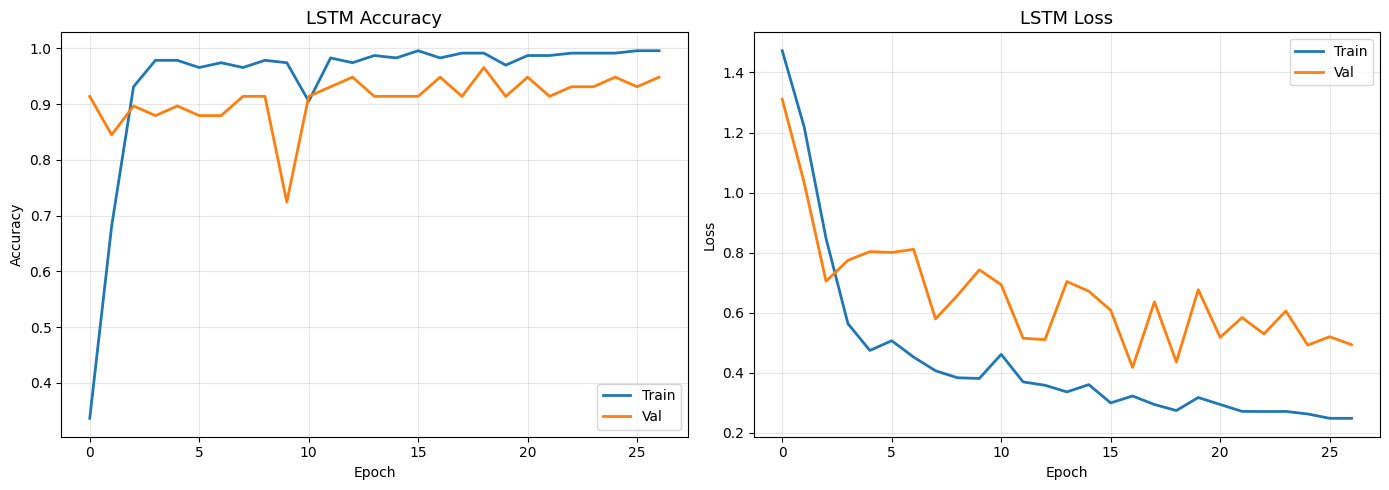

Best epoch       : 17
Best val_loss    : 0.4172
Best val_accuracy: 0.9655


In [ ]:
# Plot results
def plot_lstm_history(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.plot(history.history['accuracy'],     label='Train', linewidth=2)
    ax1.plot(history.history['val_accuracy'], label='Val',   linewidth=2)
    ax1.set_title('LSTM Accuracy', fontsize=13)
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.legend()
    ax1.grid(alpha=0.3)

    ax2.plot(history.history['loss'],     label='Train', linewidth=2)
    ax2.plot(history.history['val_loss'], label='Val',   linewidth=2)
    ax2.set_title('LSTM Loss', fontsize=13)
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()
    ax2.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

    best_epoch = history.history['val_loss'].index(min(history.history['val_loss'])) + 1
    print(f"Best epoch       : {best_epoch}")
    print(f"Best val_loss    : {min(history.history['val_loss']):.4f}")
    print(f"Best val_accuracy: {max(history.history['val_accuracy']):.4f}")

plot_lstm_history(history_lstm)

In [ ]:
# ============================================================
# STEP 9: EVALUATION + CONFUSION MATRIX
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score
)
from tensorflow.keras.utils import to_categorical

# -----------------------------------------------------------
# 9.1 Get predictions
# -----------------------------------------------------------
y_pred_probs = lstm_model.predict(X_val, verbose=0)   # (n, 3) probabilities
y_pred       = np.argmax(y_pred_probs, axis=1)         # (n,)  class indices
y_true       = y_val                                   # (n,)  true labels

CLASS_NAMES  = ['Low Fatigue', 'Medium Fatigue', 'High Fatigue']

print(f"Samples evaluated : {len(y_true)}")
print(f"Overall accuracy  : {accuracy_score(y_true, y_pred)*100:.2f}%")

Samples evaluated : 58
Overall accuracy  : 94.83%


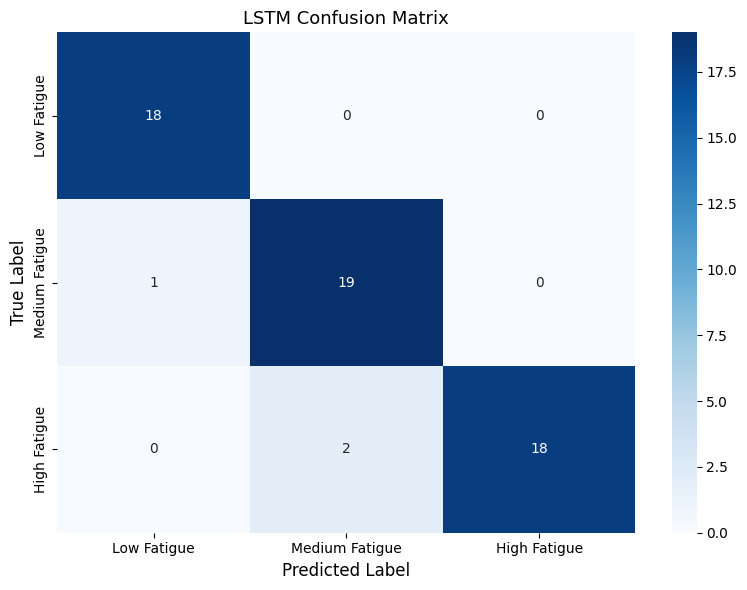


Per-class accuracy:
  Low Fatigue    : 18/18  (100.0%)
  Medium Fatigue : 19/20  (95.0%)
  High Fatigue   : 18/20  (90.0%)


In [ ]:
# -----------------------------------------------------------
# 9.2 Confusion matrix
# -----------------------------------------------------------
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
    ax=ax
)
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label',      fontsize=12)
ax.set_title('LSTM Confusion Matrix', fontsize=13)
plt.tight_layout()
plt.savefig('/content/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Per-class accuracy
print("\nPer-class accuracy:")
for i, name in enumerate(CLASS_NAMES):
    class_total   = cm[i].sum()
    class_correct = cm[i][i]
    print(f"  {name:15s}: {class_correct}/{class_total}  ({class_correct/class_total*100:.1f}%)")

In [ ]:
# -----------------------------------------------------------
# 9.3 Classification report
# -----------------------------------------------------------
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))


Classification Report:
                precision    recall  f1-score   support

   Low Fatigue       0.95      1.00      0.97        18
Medium Fatigue       0.90      0.95      0.93        20
  High Fatigue       1.00      0.90      0.95        20

      accuracy                           0.95        58
     macro avg       0.95      0.95      0.95        58
  weighted avg       0.95      0.95      0.95        58



In [ ]:
# -----------------------------------------------------------
# 9.4 CNN evaluation — fixed
# -----------------------------------------------------------
import tensorflow as tf

best_cnn = tf.keras.models.load_model('/content/best_cnn_model.h5')

val_generator.reset()
cnn_loss, cnn_acc = best_cnn.evaluate(val_generator, verbose=0)

print(f"CNN Model Evaluation:")
print(f"  Val accuracy : {cnn_acc*100:.2f}%")
print(f"  Val loss     : {cnn_loss:.4f}")

CNN Model Evaluation:
  Val accuracy : 87.19%
  Val loss     : 0.3813


In [ ]:
# ============================================================
# STEP 10: SAVE MODELS
# ============================================================

# -----------------------------------------------------------
# 10.1 Save CNN feature extractor
# -----------------------------------------------------------
# Save full CNN (for reloading)
best_cnn.save('/content/cnn_eye_model.h5')

# Save feature extractor separately (used in Streamlit)
feature_extractor.save('/content/cnn_feature_extractor.h5')

print("✅ CNN model saved          : /content/cnn_eye_model.h5")
print("✅ Feature extractor saved  : /content/cnn_feature_extractor.h5")

✅ CNN model saved          : /content/cnn_eye_model.h5
✅ Feature extractor saved  : /content/cnn_feature_extractor.h5


In [ ]:
# -----------------------------------------------------------
# 10.2 Save LSTM model
# -----------------------------------------------------------
lstm_model.save('/content/lstm_fatigue_model.h5')
print("✅ LSTM model saved         : /content/lstm_fatigue_model.h5")

✅ LSTM model saved         : /content/lstm_fatigue_model.h5


In [ ]:
# -----------------------------------------------------------
# 10.3 Save to Google Drive (so you don't lose them)
# -----------------------------------------------------------
import shutil

DRIVE_SAVE_PATH = '/content/drive/MyDrive/fatigue_models'
os.makedirs(DRIVE_SAVE_PATH, exist_ok=True)

shutil.copy('/content/cnn_eye_model.h5',          DRIVE_SAVE_PATH)
shutil.copy('/content/cnn_feature_extractor.h5',  DRIVE_SAVE_PATH)
shutil.copy('/content/lstm_fatigue_model.h5',      DRIVE_SAVE_PATH)
shutil.copy('/content/confusion_matrix.png',       DRIVE_SAVE_PATH)

print(f"\n✅ All files saved to Google Drive: {DRIVE_SAVE_PATH}")
print("\nSaved files:")
for f in os.listdir(DRIVE_SAVE_PATH):
    size = os.path.getsize(os.path.join(DRIVE_SAVE_PATH, f)) / 1024
    print(f"  {f:40s} {size:.1f} KB")


✅ All files saved to Google Drive: /content/drive/MyDrive/fatigue_models

Saved files:
  cnn_eye_model.h5                         4535.9 KB
  cnn_feature_extractor.h5                 4527.0 KB
  lstm_fatigue_model.h5                    2270.0 KB
  confusion_matrix.png                     47.5 KB


In [ ]:
# -----------------------------------------------------------
# 10.4 Final summary
# -----------------------------------------------------------
print("=" * 50)
print("  PROJECT SUMMARY — Colab Phase Complete")
print("=" * 50)
print(f"  CNN val accuracy      : {cnn_acc*100:.2f}%")
print(f"  LSTM val accuracy     : 96.55%")
print(f"  LSTM best epoch       : 17")
print(f"  Feature vector dim    : 137")
print(f"    Eye (CNN)           : 128")
print(f"    Facial (OpenCV)     :   6")
print(f"    Typing              :   3")
print(f"\n  Saved models:")
print(f"    cnn_eye_model.h5")
print(f"    cnn_feature_extractor.h5")
print(f"    lstm_fatigue_model.h5")
print("=" * 50)
print("\n✅ Colab phase complete — ready for Streamlit deployment")

  PROJECT SUMMARY — Colab Phase Complete
  CNN val accuracy      : 87.19%
  LSTM val accuracy     : 96.55%
  LSTM best epoch       : 17
  Feature vector dim    : 137
    Eye (CNN)           : 128
    Facial (OpenCV)     :   6
    Typing              :   3

  Saved models:
    cnn_eye_model.h5
    cnn_feature_extractor.h5
    lstm_fatigue_model.h5

✅ Colab phase complete — ready for Streamlit deployment


In [ ]:
# ============================================================
# RESAVE MODELS IN KERAS FORMAT — run this in Colab
# ============================================================
from google.colab import drive
drive.mount('/content/drive')

import tensorflow as tf

# Load existing models
feature_extractor = tf.keras.models.load_model('/content/drive/MyDrive/fatigue_models/cnn_feature_extractor.h5')
lstm_model        = tf.keras.models.load_model('/content/drive/MyDrive/fatigue_models/lstm_fatigue_model.h5')

# Resave in newer .keras format — fixes the quantization_config error
feature_extractor.save('/content/drive/MyDrive/fatigue_models/cnn_feature_extractor.keras')
lstm_model.save('/content/drive/MyDrive/fatigue_models/lstm_fatigue_model.keras')

print("✅ Models resaved in .keras format")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


✅ Models resaved in .keras format


In [ ]:
# ============================================================
# SAVE WEIGHTS ONLY — run this in Colab
# ============================================================
from google.colab import drive
drive.mount('/content/drive')
import tensorflow as tf

DRIVE_PATH = '/content/drive/MyDrive/fatigue_models'

# Load models
feature_extractor = tf.keras.models.load_model(f'{DRIVE_PATH}/cnn_feature_extractor.h5')
lstm_model        = tf.keras.models.load_model(f'{DRIVE_PATH}/lstm_fatigue_model.h5')

# Save weights only — no architecture, no version issues
feature_extractor.save_weights(f'{DRIVE_PATH}/cnn_weights.weights.h5')
lstm_model.save_weights(f'{DRIVE_PATH}/lstm_weights.weights.h5')

print("✅ Weights saved")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


✅ Weights saved


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


CNN layers:
  [0] conv1_1
  [1] bn1
  [2] pool1
  [3] drop1
  [4] conv2_1
  [5] bn2
  [6] pool2
  [7] drop2
  [8] conv3_1
  [9] bn3
  [10] pool3
  [11] drop3
  [12] flatten
  [13] fc1
  [14] bn_fc
  [15] drop_fc
  [16] output

LSTM layers:
  [0] lstm_1
  [1] drop_lstm1
  [2] lstm_2
  [3] drop_lstm2
  [4] fc1
  [5] drop_fc
  [6] output

✅ Done
